## Apresentação ✒️

Notebook destinado à implementação do algoritmo de clusterização K-Means, baseado na utilização de centroides para identificação dos clusters presentes em um dataset, com base na minimização da distância calculada em relação a todos os datapoints presentes. Esse algoritmo é recomendado para cenário nos quais os dados admitem separação linear - isto é, não apresentam distribuição complexa - e apresentam formato corposcular, com maior nível de isotropia. 

Da mesma forma, ele trabalha com a suposição a priori de uma quantidade de clusters presentes no dataset, diferente de outros algoritmos como o DBSCAN, os quais podem ser encontrados por meio do método conhecido como elbow ou a partir de métricas que mensuram a qualidade dos clusters identificados, como silhueta e I. Davis Bouldin. Contudo, é importante ter em mente que em alguns contextos a quantidade de clusters é concebido segundo o contexto de aplicação, sendo pré-estipulado por um time de negócios e afins. 

Importante esclarecer que o presente notebook não irá se debruçar em um workflow completo e detalhado de um processo de ciência de dados, relativo à clusterização, mas apenas passar pelas etapas mais necessárias, focando-se na implementação do algoritmo, constituindo-se de um *mise en place*, portanto.



### Library 📚

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [11]:
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pandas import DataFrame

from sklearn import metrics
from sklearn.cluster import KMeans

from sklearn.preprocessing import StandardScaler

from yellowbrick.cluster import SilhouetteVisualizer

### Carregando o dataset 💾

In [4]:
file_path = "wine-clustering.csv"

df = pd.read_csv(file_path)

df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [5]:
df.shape

(178, 13)

In [6]:
df.isnull().sum()

Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

### Explorando os dados

In [12]:
# Verificando a presença de outliers por meio do gráfico de boxplot 

# Verificando a presença de outliers nos dados por meio do recurso
# conhecido como boxplot, um gráfico que compreende a distribuição 
# dos dados, segundo um percentual conhecido como quartis. 

def boxplot(
          dataset: DataFrame, 
          style : str, 
          height : int, 
          width : int
      ):
      
      """ 
      Generates a series of boxplots for each feature in the provided dataset.

      This function uses Seaborn and Matplotlib to create boxplots for all columns in the dataset. 
      The visual style of the plots is set using the provided style parameter. The plots are arranged 
      in a grid layout with 2 rows and 3 columns, and the figure size is determined by the height and 
      width parameters.

      Args:
        dataset (DataFrame): The dataset containing the features to be visualized.
        style (str): The Seaborn style theme to be applied to the plots (e.g., "darkgrid", "whitegrid").
        height (int): The height of the overall figure.
        width (int): The width of the overall figure.

      Returns:
        None: This function displays the boxplots directly using Matplotlib's `plt.show()`.
      """

      sns.set_theme(style=style)
      
      feature = dataset.columns
      num_feature = len(feature)

       # Definir número de colunas e linhas dinamicamente
       
      num_cols = 3  
      num_rows = math.ceil(num_feature / num_cols)

      plt.figure(figsize=(width, height))

      for i, feature in enumerate(feature, 1):
          plt.subplot(num_rows, num_cols, i)  
          sns.boxplot(data=dataset[feature])  
          plt.title(f"Boxplot de {feature}")

      plt.tight_layout()
      plt.show()

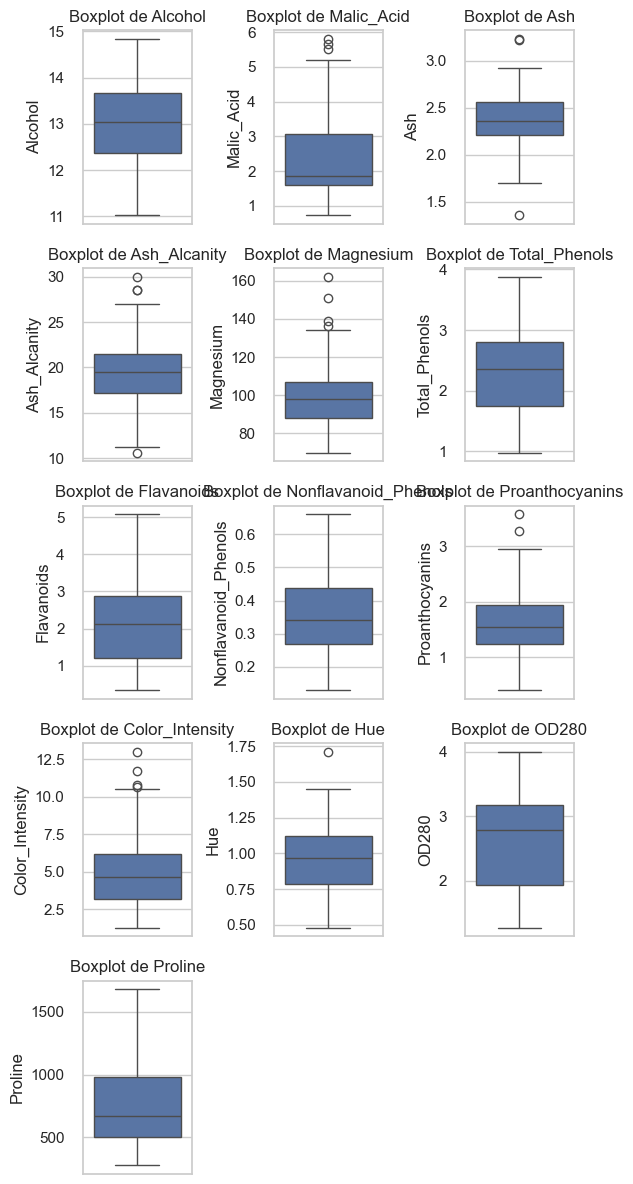

In [13]:
boxplot(
    dataset = df,
    style   = "whitegrid", 
    height  = 12, 
    width   = 6
)


Analisando o gráfico de boxplot nota-se a presença de alguns outliers na features. Como parece que a quantidade desses não é tão elevada, transformações na distribuição dos dados, como logarítimica, podem auxiliar em reduzir a assimetria existente, diminuindo a presença dos outliers. Como o presente notebook trata-se mais de um mise en place para a implementação do modelo de clusterização citado, irei apenas normalizar os dados para que fiquem numa mesma escala, aumentando a assimetria das distribuições de cada feature. 

In [14]:
# Verificando a distribuição dos dados

def data_distribuition(
        dataset: DataFrame, 
        style : str, 
        height: int, 
        width: int, 
        bins: int
        ):
    """ 
    Visualizes the distribution of each feature in the dataset using histograms.

    Parameters:
    ----------
    dataset : DataFrame
        The dataset to be visualized, where each column represents a feature.
    
    style : str
        Seaborn theme for plot styling (e.g., 'darkgrid', 'whitegrid').
    
    height : int
        The height of the figure in inches.
    
    width : int
        The width of the figure in inches.
    
    bins : int
        Number of bins for the histograms.
    """
    feature = dataset.columns
    sns.set_theme(style=style)

    # Determinar o número de linhas no grid :
    
    # Fixo para 3 colunas
    n_cols = 3 

    # Calcular o número de linhas necessárias
    n_rows = (len(feature) + n_cols - 1) // n_cols  

    plt.figure(figsize=(height, width))

    for i, feature in enumerate(feature, 1):

        data = dataset[feature]

        plt.subplot(n_rows, n_cols, i)
        sns.histplot(data, kde=True, bins=bins)
        plt.title(f"Histograma de {feature}")


    plt.tight_layout()
    plt.show()

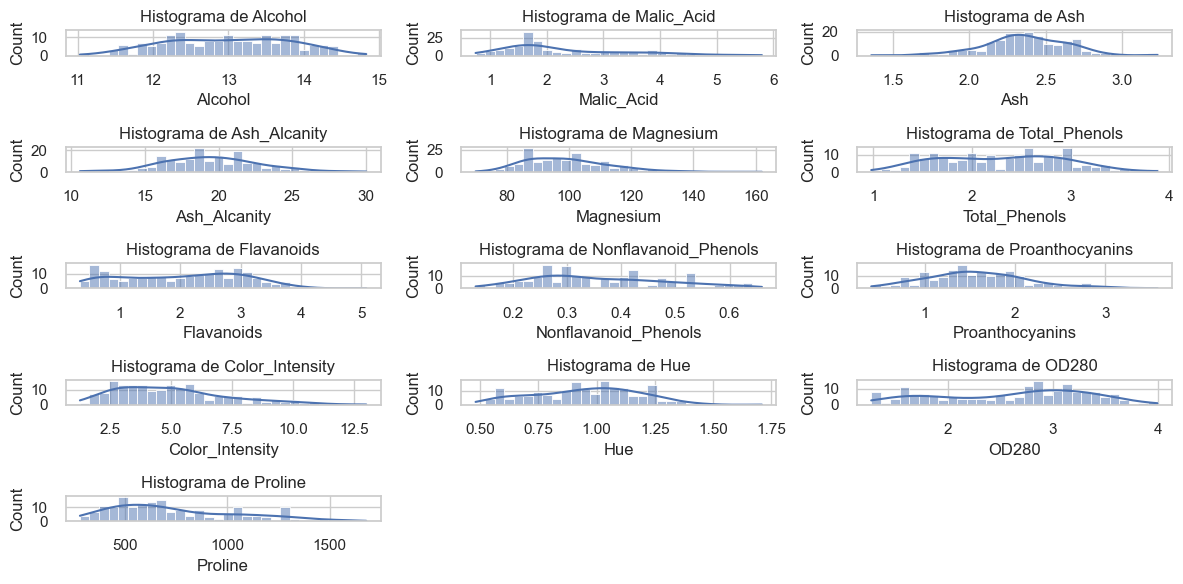

In [15]:
data_distribuition(
    dataset = df,
    style   = "whitegrid", 
    height  = 12, 
    width   = 6, 
    bins    = 30
)

### Scaler



In [16]:
standard_scaler = StandardScaler()

X = df

X_scaled = standard_scaler.fit_transform(X)

### K-Means

Um ponto de atenção é que o K-Means não apresenta a possibilidade de infomar durante a sua instanciação a distância que deseja escolher para a compreensão dos clusters presentes, com base no uso dos centroides, sendo utilizado por padrão a distância euclidiana. Caso deseje especificar a distância utilizada, deve-se utilizar de outros algoritmos, dentre os quais o K-Medoids. 

In [25]:
def find_optimal_k(
        data : DataFrame, 
        k_range : int, 
        max_iter : int, 
        n_init : int
    ) -> str:
    """ 
    Encontra o melhor número de clusters (k) para o algoritmo K-Means com base na métrica de silhueta.

    Parâmetros:
    - data (Dataframe): Conjunto de dados a ser clusterizado.
    - k_range (list ou range): Intervalo de valores de k a ser avaliado.
    - max_iter: Número máximo de iterações que o modelo pode realizar.
    - n_init (int, opcional): Número de inicializações do K-Means (padrão: 10).

    Retorna:
    - best_k (int): Número de clusters que maximiza a métrica de silhueta.
    - scores (dict): Dicionário com os valores de k e suas respectivas métricas de silhueta.
    """

    best_k = None 
    best_score = -1
    scores = {}

    for k in k_range:

        # Ajusta o modelo K-Means

        k_means = KMeans(
            n_clusters = k, 
            init       = "k-means++", 
            max_iter   = max_iter, 
            n_init     = n_init
        )

        # Identifica os clusters presentes

        labels = k_means.fit_predict(data)


        # Verificar se o número de clusters é maior que 1

        if len(set(labels)) > 1:

            # Calcular a métrica de silhueta

            score = metrics.silhouette_score(data, labels)
            scores[k] = round(float(score),3)

            # Atualizar o melhor k

            if score > best_score:
                best_k = k
                best_score = score
        else:

            # Ignorar este k, pois não é válido para silhueta
            
            scores[k] = None  

    return best_k, scores

In [27]:
best_k, scores = find_optimal_k(
    data     = X_scaled, 
    k_range  = range(1,10),
    max_iter = 300,
    n_init   = 10
)

print(f"Melhor número de clusters: {best_k}")
print(f"Métrica de silhueta: {scores}")

Melhor número de clusters: 3
Métrica de silhueta: {1: None, 2: 0.268, 3: 0.285, 4: 0.252, 5: 0.258, 6: 0.243, 7: 0.18, 8: 0.176, 9: 0.146}


In [39]:
SEED = 15

In [36]:
k_means = KMeans(
    n_clusters   = 3, 
    init         = "k-means++", 
    max_iter     = 300, 
    n_init       = 10, 
    random_state = SEED
)

In [37]:
labels = k_means.fit_predict(X_scaled)

silhoutte_score = round(metrics.silhouette_score(X_scaled, labels), 3)

print(f"A silhueta do modelo é de aproximadamente: {silhoutte_score}")

A silhueta do modelo é de aproximadamente: 0.285


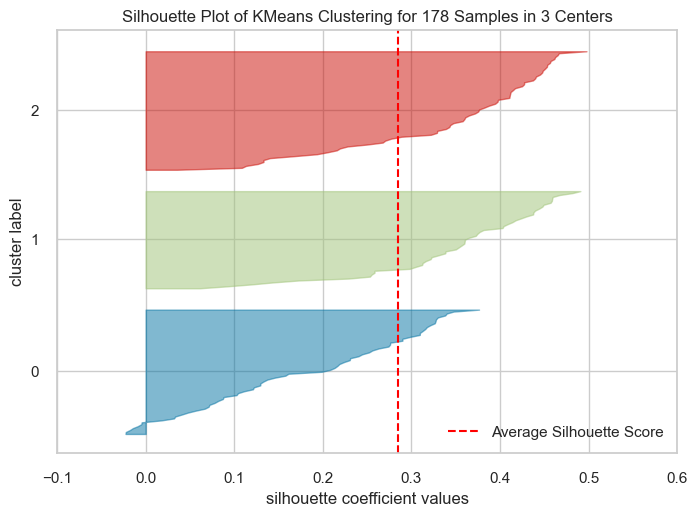

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 178 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [38]:
# Construindo uma visualização gráfica da silhueta dos clusters. 

silhoutte_view = SilhouetteVisualizer(k_means, colors="yellowbrick")
silhoutte_view.fit(X_scaled)
silhoutte_view.show()